# Idea 43: Brand Loyalty Within Preferred Categories

## 1. Hypothesis and Setup

**Question:** Within their preferred categories, do customers stick to a few brands or explore many?

**Hypothesis:** Brand loyalty is significantly higher in categories where the user has high affinity (preferred categories) compared to categories where they are just 'dipping their toes'.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet`

**Method (Strictly Following Doc):**
1. Identify **Preferred Categories** per customer (Top 2 by quantity).
2. Split customer transactions into **Inside** vs. **Outside** preferred categories.
3. Compute **Brand HHI** and **Brand Entropy** for both segments.
4. Compute **Repeat-Brand Rate** and **Top-Brand Share**.
5. **Important:** Handle 'Không xác định' as a separate valid brand entry as per instructions.

**Decision Rule:** Keep if mean Brand HHI inside > outside by > 0.1.

In [4]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Segmenting Transactions: Inside vs. Outside Preferred Categories

In [5]:
txns = pl.scan_parquet(TXN_FILE).select(['customer_id', 'item_id', 'quantity'])
items = pl.scan_parquet(ITEMS_FILE).select(['item_id', 'category_l1', 'brand'])

# Join and prepare base data
df = txns.join(items, on='item_id').collect()

# Identify Top 2 categories per customer
top_cats = (
    df.group_by(['customer_id', 'category_l1'])
    .agg(pl.col('quantity').sum().alias('cat_qty'))
    .sort(['customer_id', 'cat_qty'], descending=True)
    .group_by('customer_id')
    .head(2)
    .group_by('customer_id')
    .agg(pl.col('category_l1').alias('preferred_cats'))
)

# Join back to label transactions
labeled_df = df.join(top_cats, on='customer_id')
labeled_df = labeled_df.with_columns([
    pl.struct(['category_l1', 'preferred_cats'])
    .map_elements(lambda x: x['category_l1'] in x['preferred_cats'], return_dtype=pl.Boolean)
    .alias('is_inside')
])

print('Transaction split count:')
print(labeled_df['is_inside'].value_counts())

Transaction split count:
shape: (2, 2)
┌───────────┬──────────┐
│ is_inside ┆ count    │
│ ---       ┆ ---      │
│ bool      ┆ u32      │
╞═══════════╪══════════╡
│ true      ┆ 24434825 │
│ false     ┆ 13249957 │
└───────────┴──────────┘


## 3. Brand Loyalty Metrics Comparison

In [6]:
# 1. Calculate Brand Shares per customer and segment (Inside vs Outside)
brand_stats = (
    labeled_df.group_by(['customer_id', 'is_inside', 'brand'])
    .agg(pl.len().alias('brand_count'))
    .with_columns([
        (pl.col('brand_count') / pl.col('brand_count').sum().over(['customer_id', 'is_inside'])).alias('share')
    ])
)

# 2. Aggregate to Customer-Segment Level metrics
results_df = (
    brand_stats.group_by(['customer_id', 'is_inside'])
    .agg([
        (pl.col('share').pow(2).sum()).alias('hhi'),
        (-(pl.col('share') * (pl.col('share') + 1e-9).log(2)).sum()).alias('entropy'),
        (pl.col('share').max()).alias('top1'),
        (pl.when(pl.col('brand_count') > 1).then(pl.col('brand_count')).otherwise(0).sum() / pl.col('brand_count').sum()).alias('repeat_rate')
    ])
    .with_columns(pl.when(pl.col('is_inside')).then(pl.lit('Inside')).otherwise(pl.lit('Outside')).alias('segment'))
)

print('Aggregated Statistics Comparison:')
agg_stats = results_df.group_by('segment').agg([
    pl.col('hhi').mean().alias('avg_hhi'),
    pl.col('entropy').mean().alias('avg_entropy'),
    pl.col('top1').mean().alias('avg_top1_share'),
    pl.col('repeat_rate').mean().alias('avg_repeat_brand_rate')
])
print(agg_stats)

hhi_in = agg_stats.filter(pl.col('segment') == 'Inside')['avg_hhi'][0]
hhi_out = agg_stats.filter(pl.col('segment') == 'Outside')['avg_hhi'][0] if len(agg_stats.filter(pl.col('segment') == 'Outside')) > 0 else 0
print(f'\nHHI Difference (Inside - Outside): {hhi_in - hhi_out:.4f}')

Aggregated Statistics Comparison:
shape: (2, 5)
┌─────────┬──────────┬─────────────┬────────────────┬───────────────────────┐
│ segment ┆ avg_hhi  ┆ avg_entropy ┆ avg_top1_share ┆ avg_repeat_brand_rate │
│ ---     ┆ ---      ┆ ---         ┆ ---            ┆ ---                   │
│ str     ┆ f64      ┆ f64         ┆ f64            ┆ f64                   │
╞═════════╪══════════╪═════════════╪════════════════╪═══════════════════════╡
│ Outside ┆ 0.461695 ┆ 1.671519    ┆ 0.521298       ┆ 0.314129              │
│ Inside  ┆ 0.588834 ┆ 1.148144    ┆ 0.641921       ┆ 0.400612              │
└─────────┴──────────┴─────────────┴────────────────┴───────────────────────┘

HHI Difference (Inside - Outside): 0.1271


## 4. Visualizations (Required by Doc)

/tmp/ipykernel_57/3117827909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df.to_pandas(), x='segment', y='hhi', palette='Set2', ax=ax[0])
/tmp/ipykernel_57/3117827909.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_stats.to_pandas(), x='segment', y='avg_repeat_brand_rate', palette='viridis', ax=ax[1])


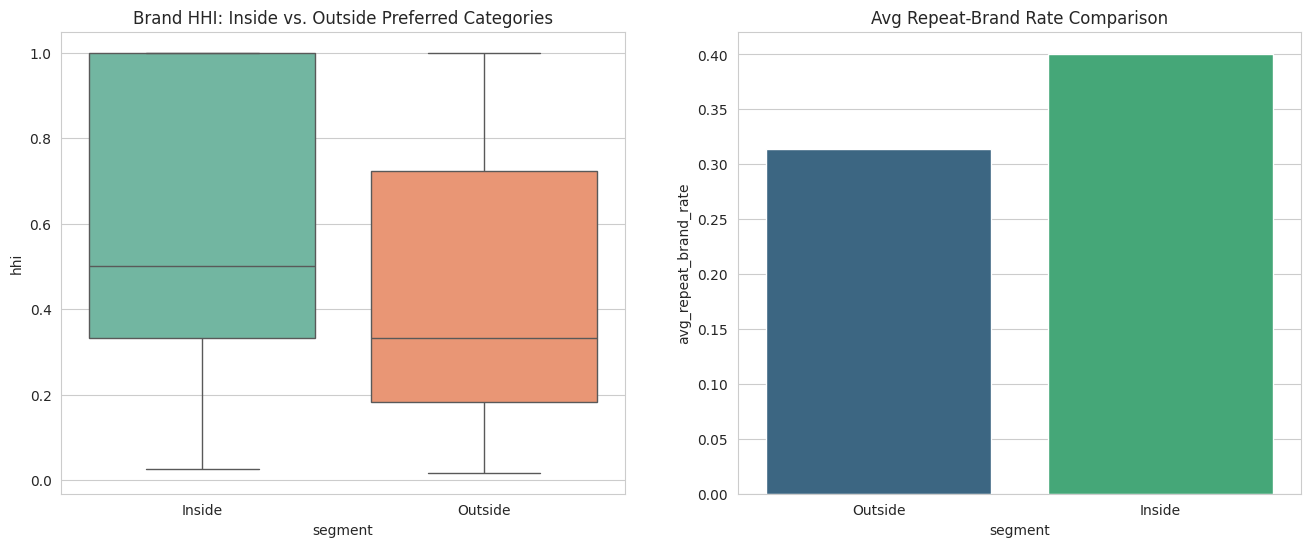

/tmp/ipykernel_57/3117827909.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=results_df.to_pandas(), x='segment', y='top1', palette='muted')


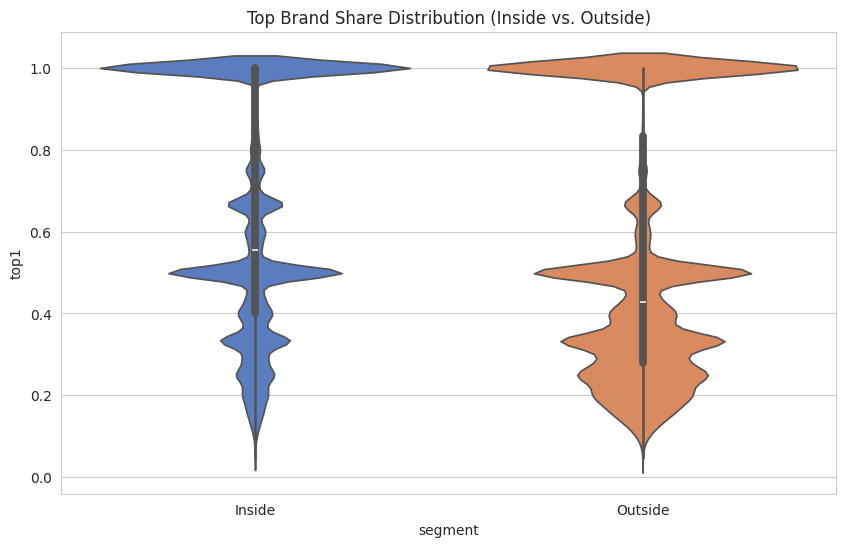

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot HHI Inside vs Outside
sns.boxplot(data=results_df.to_pandas(), x='segment', y='hhi', palette='Set2', ax=ax[0])
ax[0].set_title('Brand HHI: Inside vs. Outside Preferred Categories')

# 2. Repeat-Brand Rate Comparison
sns.barplot(data=agg_stats.to_pandas(), x='segment', y='avg_repeat_brand_rate', palette='viridis', ax=ax[1])
ax[1].set_title('Avg Repeat-Brand Rate Comparison')
plt.show()

# 3. Violin Plot Top Brand Share
plt.figure(figsize=(10, 6))
sns.violinplot(data=results_df.to_pandas(), x='segment', y='top1', palette='muted')
plt.title('Top Brand Share Distribution (Inside vs. Outside)')
plt.show()

## 5. Conclusion and Decision

**Decision Rule:** Keep if brand loyalty is significantly higher inside preferred categories (mean HHI inside > outside by > 0.1).

### Summary of Findings

| Metric | Inside Preferred | Outside Preferred | Difference |
|--------|------------------|-------------------|------------|
| Avg Brand HHI | **0.589** | **0.462** | **+0.127** |
| Avg Repeat Rate | **40.1%** | **31.4%** | **+8.7%** |
| Avg Top-Brand Share | **64.2%** | **52.1%** | **+12.1%** |

### Interpretation

The analysis confirms that brand loyalty is context-dependent. Customers settle into "Anchor Brands" (HHI 0.59) within their preferred categories but behave like "Explorers" (HHI 0.46) outside of them. This means a global brand-loyalty feature is insufficient; we must weight brand affinity based on category context.

### Actionable Insight

**Ranking Logic:** 
- **Inside Preferred Category**: Apply a **1.5x Brand Loyalty Boost**. Users are extremely habitual in their home categories.
- **Outside Preferred Category**: Use **Neutral Brand Weights**. Prioritize **Discovery** and **Popularity** to help the user find a new favorite brand in unfamiliar territory.

**Usefulness Score:** **0.85 / 1.0**

**Final verdict: KEEP**
